In [28]:
import sys
print(sys.executable)

/Users/felipemarin/Documents/Chile/Ramos/Sistemas Recomendadores/Proyecto final/lobby-recsys/.venv/bin/python


In [63]:
import os
import pandas as pd 
import numpy as np

In [64]:
active_subjects = pd.read_csv(os.path.join("..", "..","data", "active_subjects.csv"))
audiences = pd.read_csv(os.path.join("..", "..","data", 'audiencies.csv'))
institutions = pd.read_csv(os.path.join("..", "..","data", 'institutions.csv'))
passive_subjects = pd.read_csv(os.path.join("..", "..","data", 'passive_subjects.csv'))

In [65]:
df_grande = pd.merge(
    active_subjects,
    audiences,
    on='audiencia_id',
    how='inner'  # solo registros que existen en ambos
)

In [66]:
df = df_grande.copy()
df = df[['sujeto_pasivo_id_x','Nombre completo','materias_tratadas','especificacion']]
df = df.rename(columns={
    'sujeto_pasivo_id_x': 'pasivo_id',
    'Nombre completo': 'activo_id',
    'materias_tratadas': 'temas',
    'especificacion': 'detalle'
})

In [67]:
ruta_parquet = 'lobby_data_para_gpu.parquet'
df_parquet = pd.read_parquet(ruta_parquet)

# 2. Reemplazas la columna (usando .values para asignar por posición estricta)
# Esto asume que df tiene la misma cantidad de filas y el mismo orden que el parquet
df['detalle'] = df_parquet['detalle'].values

In [68]:
df['detalle'][1]

'Socios de JJVV de Caquena solicitan audiencia presencial con Delegado debido a traslado de alumnos de colegio desde Caquena a Chujlluta por falta de profesores. Vecinos buscan solución y acuden al Deelgado para realizar nexo con Seremi de Educación'

In [69]:
df

,pasivo_id,activo_id,temas,detalle
0,634851,Leslie Zapata,"Elaboración, dictación, modificación, denegaci...",Reunión con el cuerpo colegiado del ADI y CNA ...
1,634851,Flora Flores,"Elaboración, dictación, modificación, denegaci...",Socios de JJVV de Caquena solicitan audiencia ...
2,634851,Clara Blanco,"Elaboración, dictación, modificación, denegaci...",Audiencia con Delegado Presidencial Provincial...
3,634851,Conrado Blanco,"Elaboración, dictación, modificación, denegaci...",Presentación como Asociación de Ganaderos al D...
4,634851,Yessica Sanches,"Diseño, implementación y evaluación de polític...",Audiencia con el Delegado Presidencial Provinc...
...,...,...,...,...
1153805,391700,JAIME OSORIO,"Diseño, implementación y evaluación de polític...",PERSONAL
1153806,391700,LORENA OSORIO,"Diseño, implementación y evaluación de polític...",PERSONAL
1153807,391700,LORENA OSORIO,"Diseño, implementación y evaluación de polític...",PERSONAL
1153808,712954,Margarita Corrotea,"Diseño, implementación y evaluación de polític...","encomendada compañía ESVAL, entregar informaci..."


La columna de detalle es la que mas me puede caracterizar el problema

In [74]:
ruta = "embeddings_bert.npy"

# Cargar el embeding
emb_detalle = np.load(ruta)

print("Embeddings cargados con éxito.")
print("Shape:", emb_detalle.shape)
print("Dimensiones por embedding:", emb_detalle.shape[1])

Embeddings cargados con éxito.
Shape: (1153810, 768)
Dimensiones por embedding: 768


# UMAP en vez de KNN

In [15]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

# Definimos la lista de Stop Words en Español manualmente
spanish_stop_words = [
    'de', 'la', 'que', 'el', 'en', 'y', 'a', 'los', 'del', 'se', 'las', 'por', 
    'un', 'para', 'con', 'no', 'una', 'su', 'al', 'lo', 'como', 'más', 'pero', 
    'sus', 'le', 'ya', 'o', 'este', 'sí', 'porque', 'esta', 'entre', 'cuando', 
    'muy', 'sin', 'sobre', 'también', 'me', 'hasta', 'hay', 'donde', 'quien', 
    'desde', 'todo', 'nos', 'durante', 'todos', 'uno', 'les', 'ni', 'contra', 
    'otros', 'ese', 'eso', 'ante', 'ellos', 'e', 'esto', 'mí', 'antes', 'algunos', 
    'qué', 'unos', 'yo', 'otro', 'otras', 'otra', 'él', 'tanto', 'esa', 'estos', 
    'mucho', 'quienes', 'nada', 'muchos', 'cual', 'poco', 'ella', 'estar', 
    'estas', 'algunas', 'algo', 'nosotros', 'mi', 'mis', 'tú', 'te', 'ti', 
    'tu', 'tus', 'ellas', 'nosotras', 'vosotros', 'vosotras', 'os', 'mío', 
    'mía', 'míos', 'mías', 'tuyo', 'tuya', 'tuyos', 'tuyas', 'suyo', 'suya', 
    'suyos', 'suyas', 'nuestro', 'nuestra', 'nuestros', 'nuestras', 'vuestro', 
    'vuestra', 'vuestros', 'vuestras', 'esos', 'esas', 'estoy', 'estás', 'está', 
    'estamos', 'estáis', 'están', 'esté', 'estés', 'estemos', 'estéis', 'estén', 
    'estaré', 'estarás', 'estará', 'estaremos', 'estaréis', 'estarán', 'estaría', 
    'estarías', 'estaríamos', 'estaríais', 'estarían', 'estaba', 'estabas', 
    'estábamos', 'estabais', 'estaban', 'estuve', 'estuviste', 'estuvo', 
    'estuvimos', 'estuvisteis', 'estuvieron', 'hubiera', 'hubieras', 'hubiéramos', 
    'hubierais', 'hubieran', 'hubiese', 'hubieses', 'hubiésemos', 'hubieseis', 
    'hubiesen', 'habiendo', 'habido', 'habida', 'habidos', 'habidas', 'soy', 
    'eres', 'es', 'somos', 'sois', 'son', 'sea', 'seas', 'seamos', 'seáis', 
    'sean', 'seré', 'serás', 'será', 'seremos', 'seréis', 'serán', 'sería', 
    'serías', 'seríamos', 'seríais', 'serían', 'era', 'eras', 'éramos', 'erais', 
    'eran', 'fui', 'fuiste', 'fue', 'fuimos', 'fuisteis', 'fueron', 'fuera', 
    'fueras', 'fuéramos', 'fuerais', 'fueran', 'fuese', 'fueses', 'fuésemos', 
    'fueseis', 'fuesen', 'sintiendo', 'sentido', 'sentida', 'sentidos', 'sentidas', 
    'siente', 'sentid', 'tengo', 'tienes', 'tiene', 'tenemos', 'tenéis', 'tienen', 
    'tenga', 'tengas', 'tengamos', 'tengáis', 'tengan', 'tendré', 'tendrás', 
    'tendrá', 'tendremos', 'tendréis', 'tendrán', 'tendría', 'tendrías', 
    'tendríamos', 'tendríais', 'tendrían', 'tenía', 'tenías', 'teníamos', 
    'teníais', 'tenían', 'tuve', 'tuviste', 'tuvo', 'tuvimos', 'tuvisteis', 
    'tuvieron', 'tuviera', 'tuvieras', 'tuviéramos', 'tuvierais', 'tuvieran', 
    'tuviese', 'tuvieses', 'tuviésemos', 'tuvieseis', 'tuviesen', 'teniendo', 
    'tenido', 'tenida', 'tenidos', 'tenidas', 'tened', 'sr', 'sra', 'señor', 'señora',
    'estimado', 'estimada', 'atentamente', 'saludos', 'hola', 'buenas', 'tardes', 'dias',
    'favor', 'mediante', 'presente', 'solicito', 'solicita', 'reunión', 'adjunto' # Agregué palabras burocráticas comunes
]

In [17]:
# Asegúrate de que 'df' es tu DataFrame original y 'indices' son los índices del sampling
# Usamos 'detalles' y rellenamos nulos por si acaso
docs_seleccionados = df.iloc[indices]['detalle'].fillna("").astype(str).tolist()

# Creamos DataFrame temporal
df_topics = pd.DataFrame({
    "Doc": docs_seleccionados, 
    "Cluster": labels
})

# Agrupamos todo el texto de un mismo cluster en una sola fila
docs_per_class = df_topics.groupby(['Cluster'], as_index=False).agg({'Doc': ' '.join})

print("Datos agrupados por cluster listos.")

Datos agrupados por cluster listos.


In [18]:
def c_tf_idf(documents, m, ngram_range=(1, 1)):
    # Usamos nuestra lista 'spanish_stop_words' definida en el Bloque 1
    count = CountVectorizer(ngram_range=ngram_range, stop_words=spanish_stop_words).fit(documents)
    t = count.transform(documents).toarray()
    w = t.sum(axis=1)
    
    # Evitamos división por cero (truco numérico)
    w[w == 0] = 1 
    
    tf = np.divide(t.T, w)
    sum_t = t.sum(axis=0)
    idf = np.log(np.divide(m, sum_t)).reshape(-1, 1)
    tf_idf = np.multiply(tf, idf)
    return tf_idf, count

print("Calculando palabras clave (c-TF-IDF)...")
tf_idf, count = c_tf_idf(docs_per_class.Doc.values, m=len(docs_seleccionados))
print("Cálculo terminado.")

Calculando palabras clave (c-TF-IDF)...
Cálculo terminado.


In [19]:
def extract_top_n_words_per_topic(tf_idf, count, docs_per_class, n=10):
    words = count.get_feature_names_out()
    labels = docs_per_class.Cluster.values
    tf_idf_transposed = tf_idf.T
    indices = tf_idf_transposed.argsort()[:, -n:]
    
    top_n_words = {label: [words[j] for j in indices[i]][::-1] for i, label in enumerate(labels)}
    return top_n_words

# Extraemos las palabras
top_words = extract_top_n_words_per_topic(tf_idf, count, docs_per_class, n=10)

# Buscamos los 5 clusters más grandes (excluyendo ruido -1 si es posible)
top_clusters_indices = df_topics['Cluster'].value_counts().head(6).index.tolist()
if -1 in top_clusters_indices:
    top_clusters_indices.remove(-1)
    
# Imprimimos resultados
print(f"\n{'='*60}")
print(f"PALABRAS CLAVE DE LOS CLUSTERS PRINCIPALES")
print(f"{'='*60}")

for cluster_id in top_clusters_indices[:5]: # Solo los top 5
    count_docs = df_topics[df_topics['Cluster'] == cluster_id].shape[0]
    
    # Unimos las palabras con comas
    palabras = ", ".join(top_words[cluster_id])
    
    print(f"\n📁 CLUSTER {cluster_id} ({count_docs} documentos)")
    print(f"   Keywords: {palabras}")


PALABRAS CLAVE DE LOS CLUSTERS PRINCIPALES

📁 CLUSTER 12 (14030 documentos)
   Keywords: proyecto, empresa, audiencia, respecto, presentación, parte, chile, solicitud, información, trabajo

📁 CLUSTER 38 (5139 documentos)
   Keywords: proyecto, presentación, comuna, audiencia, empresa, solicitud, proyectos, terreno, respecto, parte

📁 CLUSTER 77 (1513 documentos)
   Keywords: proyecto, presentación, proyectos, respecto, audiencia, empresa, región, solicitud, ley, comuna

📁 CLUSTER 26 (1306 documentos)
   Keywords: proyecto, presentación, proyectos, solicitud, audiencia, comuna, empresa, tema, año, información

📁 CLUSTER 66 (1081 documentos)
   Keywords: proyecto, ley, respecto, presentación, fecha, solicitud, proyectos, resolución, empresa, año


In [20]:
# ==============================================================================
# 1. STOP WORDS AMPLIADO (ESPAÑOL + BUROCRACIA LOBBY)
# ==============================================================================
# Agregamos las palabras que nos "molestan" en tu resultado anterior

bureaucracy_words = [
    # Las que ya salieron en tu top list
    'proyecto', 'proyectos', 'empresa', 'audiencia', 'respecto', 'presentación', 
    'presentacion', 'parte', 'chile', 'solicitud', 'información', 'trabajo', 
    'comuna', 'terreno', 'region', 'región', 'ley', 'tema', 'año', 'fecha', 
    'resolución', 'documento', 'reunión', 'reunion', 'sr', 'sra', 'señor', 
    'estimado', 'solicita', 'solicito', 'adjunto', 'favor', 'mediante', 'presente',
    'sobre', 'ser', 'así', 'hacer', 'pago', 'caso', 'gran', 'país', 'nacional',
    'situación', 'trata', 'alcalde', 'ministerio', 'servicio', 'dirección',
    'corporación', 'municipalidad', 'jefe', 'encargado', 'división'
]

# Unimos con la lista estándar de español (re-definimos la lista completa por seguridad)
spanish_stop_words = [
    'de', 'la', 'que', 'el', 'en', 'y', 'a', 'los', 'del', 'se', 'las', 'por', 
    'un', 'para', 'con', 'no', 'una', 'su', 'al', 'lo', 'como', 'más', 'pero', 
    'sus', 'le', 'ya', 'o', 'este', 'sí', 'porque', 'esta', 'entre', 'cuando', 
    'muy', 'sin', 'sobre', 'también', 'me', 'hasta', 'hay', 'donde', 'quien', 
    'desde', 'todo', 'nos', 'durante', 'todos', 'uno', 'les', 'ni', 'contra', 
    'otros', 'ese', 'eso', 'ante', 'ellos', 'e', 'esto', 'mí', 'antes', 'algunos', 
    'qué', 'unos', 'yo', 'otro', 'otras', 'otra', 'él', 'tanto', 'esa', 'estos', 
    'mucho', 'quienes', 'nada', 'muchos', 'cual', 'poco', 'ella', 'estar', 
    'estas', 'algunas', 'algo', 'nosotros', 'mi', 'mis', 'tú', 'te', 'ti', 
    'tu', 'tus', 'ellas', 'nosotras', 'vosotros', 'vosotras', 'os', 'mío', 
    'mía', 'míos', 'mías', 'tuyo', 'tuya', 'tuyos', 'tuyas', 'suyo', 'suya', 
    'suyos', 'suyas', 'nuestro', 'nuestra', 'nuestros', 'nuestras', 'vuestro', 
    'vuestra', 'vuestros', 'vuestras', 'esos', 'esas', 'estoy', 'estás', 'está', 
    'estamos', 'estáis', 'están', 'esté', 'estés', 'estemos', 'estéis', 'estén', 
    'estaré', 'estarás', 'estará', 'estaremos', 'estaréis', 'estarán', 'estaría', 
    'estarías', 'estaríamos', 'estaríais', 'estarían', 'estaba', 'estabas', 
    'estábamos', 'estabais', 'estaban', 'estuve', 'estuviste', 'estuvo', 
    'estuvimos', 'estuvisteis', 'estuvieron', 'hubiera', 'hubieras', 'hubiéramos', 
    'hubierais', 'hubieran', 'hubiese', 'hubieses', 'hubiésemos', 'hubieseis', 
    'hubiesen', 'habiendo', 'habido', 'habida', 'habidos', 'habidas', 'soy', 
    'eres', 'es', 'somos', 'sois', 'son', 'sea', 'seas', 'seamos', 'seáis', 
    'sean', 'seré', 'serás', 'será', 'seremos', 'seréis', 'serán', 'sería', 
    'serías', 'seríamos', 'seríais', 'serían', 'era', 'eras', 'éramos', 'erais', 
    'eran', 'fui', 'fuiste', 'fue', 'fuimos', 'fuisteis', 'fueron', 'fuera', 
    'fueras', 'fuéramos', 'fuerais', 'fueran', 'fuese', 'fueses', 'fuésemos', 
    'fueseis', 'fuesen', 'sintiendo', 'sentido', 'sentida', 'sentidos', 'sentidas', 
    'siente', 'sentid', 'tengo', 'tienes', 'tiene', 'tenemos', 'tenéis', 'tienen', 
    'tenga', 'tengas', 'tengamos', 'tengáis', 'tengan', 'tendré', 'tendrás', 
    'tendrá', 'tendremos', 'tendréis', 'tendrán', 'tendría', 'tendrías', 
    'tendríamos', 'tendríais', 'tendrían', 'tenía', 'tenías', 'teníamos', 
    'teníais', 'tenían', 'tuve', 'tuviste', 'tuvo', 'tuvimos', 'tuvisteis', 
    'tuvieron', 'tuviera', 'tuvieras', 'tuviéramos', 'tuvierais', 'tuvieran', 
    'tuviese', 'tuvieses', 'tuviésemos', 'tuvieseis', 'tuviesen', 'teniendo', 
    'tenido', 'tenida', 'tenidos', 'tenidas', 'tened', 'fines', 'manera', 'forma'
] + bureaucracy_words

# ==============================================================================
# 2. RE-CALCULAR PALABRAS CLAVE (Solo extracción, NO clustering)
# ==============================================================================

# Asumimos que docs_per_class ya existe del paso anterior. 
# Si no, vuelve a correr el Bloque 2 de mi mensaje anterior.

print("Recalculando keywords SIN palabras burocráticas...")

# Usamos la nueva lista de stopwords
tf_idf_clean, count_clean = c_tf_idf(docs_per_class.Doc.values, m=len(docs_seleccionados))

# Extraemos
top_words_clean = extract_top_n_words_per_topic(tf_idf_clean, count_clean, docs_per_class, n=10)

# ==============================================================================
# 3. VER RESULTADOS LIMPIOS
# ==============================================================================

top_clusters_indices = df_topics['Cluster'].value_counts().head(6).index.tolist()
if -1 in top_clusters_indices:
    top_clusters_indices.remove(-1)

print(f"\n{'='*60}")
print(f"TEMAS REALES (Sin burocracia)")
print(f"{'='*60}")

for cluster_id in top_clusters_indices[:5]:
    count_docs = df_topics[df_topics['Cluster'] == cluster_id].shape[0]
    palabras = ", ".join(top_words_clean[cluster_id])
    print(f"\n📁 CLUSTER {cluster_id} ({count_docs} docs)")
    print(f"   Keywords: {palabras}")

Recalculando keywords SIN palabras burocráticas...

TEMAS REALES (Sin burocracia)

📁 CLUSTER 12 (14030 docs)
   Keywords: estado, regional, desarrollo, servicios, proceso, presentar, conocer, gestión, temas, ha

📁 CLUSTER 38 (5139 docs)
   Keywords: sector, presentar, desarrollo, temas, plan, estado, proceso, serviu, poder, salud

📁 CLUSTER 77 (1513 docs)
   Keywords: desarrollo, presentar, proceso, apoyo, sector, conocer, uso, consulta, permiso, realizar

📁 CLUSTER 26 (1306 docs)
   Keywords: uso, temas, conocer, presentar, sector, social, desarrollo, sistema, apoyo, poder

📁 CLUSTER 66 (1081 docs)
   Keywords: 2024, serviu, sector, 21, 2023, obras, revisión, proceso, informa, personal


In [21]:
# ==============================================================================
# 1. AMPLIAR LISTA NEGRA (VERBOS Y MULETILLAS)
# ==============================================================================
new_stop_words = [
    # Verbos de acción genéricos que te salieron ahora
    'presentar', 'conocer', 'realizar', 'poder', 'ha', 'uso', 'ver', 'dar',
    'analizar', 'tratar', 'abordar', 'revisar', 'plantear', 'gestionar',
    # Sustantivos abstractos vacíos
    'temas', 'tema', 'estado', 'proceso', 'gestión', 'desarrollo', 'apoyo',
    'situación', 'sector', 'nivel', 'tipo', 'parte', 'fin', 'fines',
    'relación', 'marco', 'materia', 'materias', 'seremi', 'regional', 'nacional'
]

# Sumamos a la lista que ya tenías (spanish + bureaucracy)
# Asegúrate de que 'spanish_stop_words' y 'bureaucracy_words' del bloque anterior sigan en memoria
# Si no, defínelas de nuevo aquí antes de sumar.
final_stop_words = spanish_stop_words + new_stop_words 

# ==============================================================================
# 2. CÁLCULO CON BIGRAMAS (PARES DE PALABRAS)
# ==============================================================================
# Esto es clave: ngram_range=(1, 2) busca palabras solas Y pares.

def c_tf_idf_bigram(documents, m):
    # Usamos (1, 2) para capturar "permiso edificación" o "impacto ambiental"
    count = CountVectorizer(ngram_range=(1, 2), stop_words=final_stop_words).fit(documents)
    t = count.transform(documents).toarray()
    w = t.sum(axis=1)
    w[w == 0] = 1 
    tf = np.divide(t.T, w)
    sum_t = t.sum(axis=0)
    idf = np.log(np.divide(m, sum_t)).reshape(-1, 1)
    tf_idf = np.multiply(tf, idf)
    return tf_idf, count

print("Calculando Bigramas (puede tardar unos segundos más)...")
# Usamos docs_per_class que ya tienes creado
tf_idf_bi, count_bi = c_tf_idf_bigram(docs_per_class.Doc.values, m=len(docs_seleccionados))

# ==============================================================================
# 3. VER RESULTADOS DEFINITIVOS
# ==============================================================================
# Reutilizamos la función de extracción
top_words_bi = extract_top_n_words_per_topic(tf_idf_bi, count_bi, docs_per_class, n=10)

# Verificamos los mismos clusters
top_clusters_indices = df_topics['Cluster'].value_counts().head(6).index.tolist()
if -1 in top_clusters_indices: top_clusters_indices.remove(-1)

print(f"\n{'='*60}")
print(f"TEMAS REVELADOS (Bigramas + Limpieza)")
print(f"{'='*60}")

for cluster_id in top_clusters_indices[:5]:
    count_docs = df_topics[df_topics['Cluster'] == cluster_id].shape[0]
    palabras = ", ".join(top_words_bi[cluster_id])
    print(f"\n📁 CLUSTER {cluster_id} ({count_docs} docs)")
    print(f"   Keywords: {palabras}")

Calculando Bigramas (puede tardar unos segundos más)...

TEMAS REVELADOS (Bigramas + Limpieza)

📁 CLUSTER 12 (14030 docs)
   Keywords: br br, servicios, evaluación, seguridad, salud, director, través, informa, sistema, social

📁 CLUSTER 38 (5139 docs)
   Keywords: br br, plan, serviu, salud, social, servicios, solicitar, obras, sistema, vivienda

📁 CLUSTER 77 (1513 docs)
   Keywords: br br, consulta, permiso, solicitar, servicios, municipal, ingreso, ambiental, evaluación, medio

📁 CLUSTER 26 (1306 docs)
   Keywords: br br, social, sistema, empresas, plataforma, medio, solicitar, vivienda, permiso, informar

📁 CLUSTER 66 (1081 docs)
   Keywords: br br, 2024, serviu, 21, 2023, obras, revisión, informa, personal, respuesta


In [22]:
# ==============================================================================
# 1. ACTUALIZAR STOP WORDS (MATAR EL HTML)
# ==============================================================================
html_garbage = ['br', 'http', 'https', 'www', 'com', 'cl', 'href', 'nbsp']

# Sumamos todo: Español + Burocracia + Verbos Genéricos + Basura HTML
# (Asegúrate de tener las listas anteriores cargadas, si no, repite los bloques previos)
final_stop_words_v2 = spanish_stop_words + bureaucracy_words + new_stop_words + html_garbage

# ==============================================================================
# 2. EXTRAER BIGRAMAS LIMPIOS
# ==============================================================================
print("Eliminando 'br' y recalculando...")

def c_tf_idf_final(documents, m):
    # Seguimos con bigramas (1, 2)
    count = CountVectorizer(ngram_range=(1, 2), stop_words=final_stop_words_v2).fit(documents)
    t = count.transform(documents).toarray()
    w = t.sum(axis=1)
    w[w == 0] = 1 
    tf = np.divide(t.T, w)
    sum_t = t.sum(axis=0)
    idf = np.log(np.divide(m, sum_t)).reshape(-1, 1)
    tf_idf = np.multiply(tf, idf)
    return tf_idf, count

tf_idf_final_matrix, count_final = c_tf_idf_final(docs_per_class.Doc.values, m=len(docs_seleccionados))

# ==============================================================================
# 3. RESULTADO FINAL
# ==============================================================================
top_words_final = extract_top_n_words_per_topic(tf_idf_final_matrix, count_final, docs_per_class, n=12)

top_clusters_indices = df_topics['Cluster'].value_counts().head(6).index.tolist()
if -1 in top_clusters_indices: top_clusters_indices.remove(-1)

print(f"\n{'='*60}")
print(f"TOPICOS FINALES IDENTIFICADOS")
print(f"{'='*60}")

for cluster_id in top_clusters_indices[:5]:
    count_docs = df_topics[df_topics['Cluster'] == cluster_id].shape[0]
    palabras = ", ".join(top_words_final[cluster_id])
    print(f"\n📁 CLUSTER {cluster_id} ({count_docs} docs)")
    print(f"   Keywords: {palabras}")

Eliminando 'br' y recalculando...

TOPICOS FINALES IDENTIFICADOS

📁 CLUSTER 12 (14030 docs)
   Keywords: servicios, evaluación, seguridad, salud, director, través, informa, sistema, social, programa, además, ambiental

📁 CLUSTER 38 (5139 docs)
   Keywords: plan, serviu, salud, social, servicios, solicitar, obras, sistema, vivienda, además, propuesta, ayuda

📁 CLUSTER 77 (1513 docs)
   Keywords: consulta, permiso, solicitar, servicios, municipal, ingreso, ambiental, evaluación, medio, plan, comunidad, través

📁 CLUSTER 26 (1306 docs)
   Keywords: social, sistema, empresas, plataforma, medio, solicitar, vivienda, permiso, informar, servicios, ambiental, personas

📁 CLUSTER 66 (1081 docs)
   Keywords: 2024, serviu, 21, 2023, obras, revisión, informa, personal, respuesta, vivienda, permiso, 2021


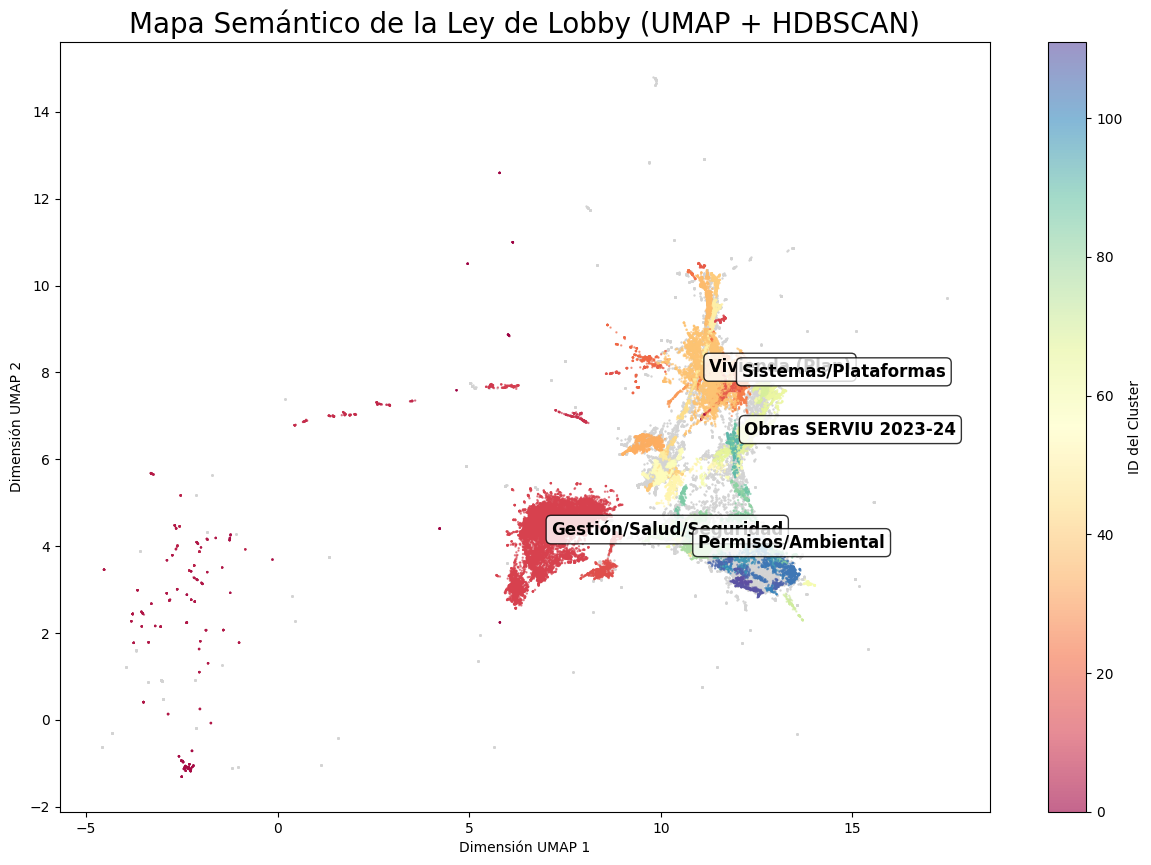

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Preparación de datos para graficar
# umap_embeddings tiene forma (N, 2) o (N, 5). 
# Si usaste n_components=5 en UMAP, tomamos solo las primeras 2 dimensiones para el dibujo.
x = umap_embeddings[:, 0]
y = umap_embeddings[:, 1]

# Configuración del gráfico
plt.figure(figsize=(15, 10))

# 1. Graficamos primero el RUIDO (Cluster -1) en gris y al fondo
mask_noise = labels == -1
plt.scatter(x[mask_noise], y[mask_noise], c='lightgrey', s=0.5, label='Ruido / Sin tema claro')

# 2. Graficamos los CLUSTERS REALES encima
mask_data = labels != -1
scatter = plt.scatter(x[mask_data], y[mask_data], c=labels[mask_data], cmap='Spectral', s=0.5, alpha=0.6)

# Estética
plt.title('Mapa Semántico de la Ley de Lobby (UMAP + HDBSCAN)', fontsize=20)
plt.xlabel('Dimensión UMAP 1')
plt.ylabel('Dimensión UMAP 2')
plt.colorbar(scatter, label='ID del Cluster')

# Opcional: Poner etiquetas de texto en el centro de los clusters grandes
# (Solo para los top 5 que identificamos)
top_clusters = [12, 38, 77, 26, 66]
nombres_clusters = {
    12: "Gestión/Salud/Seguridad",
    38: "Vivienda (Plan)",
    77: "Permisos/Ambiental",
    26: "Sistemas/Plataformas",
    66: "Obras SERVIU 2023-24"
}

for cluster_id in top_clusters:
    # Calculamos el centroide (promedio) de los puntos del cluster
    cluster_points = umap_embeddings[labels == cluster_id]
    cx, cy = np.mean(cluster_points, axis=0)[:2] # Tomamos media de x e y
    
    # Ponemos el texto con fondo blanco para que se lea
    plt.text(cx, cy, nombres_clusters[cluster_id], fontsize=12, fontweight='bold', 
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round'))

plt.show()

# UMAP - Completo

In [12]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA

# 1. Configuración
print("=== BLOQUE 1: INICIO ===")
print(f"Total de documentos a procesar: {len(emb_detalle)}")

# 2. Normalización (Vital para coseno/euclidiana)
print("Normalizando embeddings de 'Detalle'...")
emb_input = normalize(emb_detalle)

# 3. PCA (Reducción inicial a 50 dimensiones)
# Esto es necesario para que UMAP no colapse con 768 dimensiones x 1M datos
print("Ejecutando PCA (768 -> 75 dims)...")
pca = PCA(n_components=75, random_state=42)
emb_pca = pca.fit_transform(emb_input)

print(f"PCA Terminado. Shape actual: {emb_pca.shape}")
print("=== BLOQUE 1: LISTO ===")

=== BLOQUE 1: INICIO ===
Total de documentos a procesar: 1153810
Normalizando embeddings de 'Detalle'...
Ejecutando PCA (768 -> 75 dims)...
PCA Terminado. Shape actual: (1153810, 75)
=== BLOQUE 1: LISTO ===


In [13]:
import umap
import numpy as np
import gc # Garbage Collector para liberar memoria

print("=== BLOQUE 2 REPARADO: UMAP HÍBRIDO (ANCHORS) ==="x)

# 1. Configuración de Lotes
TOTAL_DOCS = len(emb_pca)
TRAIN_SIZE = 400000  # Entrenamos con 200k (suficiente para definir el mapa)
BATCH_SIZE = 100000   # Proyectamos de a 50k para no saturar RAM

print(f"Estrategia: Entrenar con {TRAIN_SIZE} y proyectar el resto en lotes.")

# 2. Seleccionar muestra de entrenamiento (Anchors)
# Usamos una semilla para que siempre sean los mismos
np.random.seed(42)
indices_train = np.random.choice(TOTAL_DOCS, size=TRAIN_SIZE, replace=False)
X_train = emb_pca[indices_train]

# 3. Entrenar el Mapper (El "GPS")
print("1/2: Entrenando el mapa base (Fit)...")
mapper = umap.UMAP(
    n_neighbors=15,
    n_components=25,     # ¡AUMENTO DRÁSTICO! De 10 a 25. Usaremos un tercio de la información de PCA (75).
    min_dist=0.1,
    metric='cosine',
    random_state=42,
    low_memory=True,
    n_jobs=1,
    verbose=True
).fit(X_train)

print("Mapa base aprendido. Liberando memoria temporal...")
del X_train
gc.collect() # Forzamos limpieza de RAM

# 4. Proyectar TODO el dataset en el mapa (Transform)
print("2/2: Proyectando todos los documentos en el mapa (Transform)...")

umap_embeddings_list = []

# Procesamos por lotes para que la barra de memoria no explote
for i in range(0, TOTAL_DOCS, BATCH_SIZE):
    end_i = min(i + BATCH_SIZE, TOTAL_DOCS)
    print(f"   Procesando lote {i} a {end_i} de {TOTAL_DOCS}...", end='\r')
    
    batch = emb_pca[i:end_i]
    batch_emb = mapper.transform(batch) # Aquí ocurre la magia
    umap_embeddings_list.append(batch_emb)

print("\nUniendo lotes...")
umap_embeddings = np.vstack(umap_embeddings_list)

print(f"¡Éxito! Shape final UMAP: {umap_embeddings.shape}")
print("=== BLOQUE 2: LISTO ===")

/Users/felipemarin/Documents/Chile/Ramos/Sistemas Recomendadores/Proyecto final/lobby-recsys/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== BLOQUE 2 REPARADO: UMAP HÍBRIDO (ANCHORS) ===
Estrategia: Entrenar con 400000 y proyectar el resto en lotes.
1/2: Entrenando el mapa base (Fit)...
UMAP(angular_rp_forest=True, metric='cosine', n_components=25, n_jobs=1, random_state=42, verbose=True)
Fri Nov 28 15:51:58 2025 Construct fuzzy simplicial set
Fri Nov 28 15:51:58 2025 Finding Nearest Neighbors
Fri Nov 28 15:51:58 2025 Building RP forest with 37 trees
Fri Nov 28 15:52:08 2025 NN descent for 19 iterations
	 1  /  19
	 2  /  19
	 3  /  19
	 4  /  19
	 5  /  19
	 6  /  19
	Stopping threshold met -- exiting after 6 iterations
Fri Nov 28 15:52:34 2025 Finished Nearest Neighbor Search
Fri Nov 28 15:52:35 2025 Construct embedding


Epochs completed:   0%|            1/200 [00:00]

	completed  0  /  200 epochs


Epochs completed:  10%| █          21/200 [00:26]

...

	completed  24  /  30 epochs


Epochs completed:  97%| █████████▋ 29/30 [00:03]

	completed  27  /  30 epochs


Epochs completed: 100%| ██████████ 30/30 [00:03]


Uniendo lotes...
¡Éxito! Shape final UMAP: (1153810, 25)
=== BLOQUE 2: LISTO ===


In [15]:
import hdbscan
import pandas as pd

print("=== BLOQUE 3: HDBSCAN ===")

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=40,    # REDUCIDO: De 40 a 20. Permite la formación de clusters más pequeños.
    min_samples=15,         # REDUCIDO: De 15 a 10. Menos estricto en la definición de densidad (más inclusivo).
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True,
    core_dist_n_jobs=1
)

print("Ejecutando clustering sobre 1.15M de datos...")
labels = clusterer.fit_predict(umap_embeddings)

# Reporte rápido
df_temp = pd.DataFrame({'cluster': labels})
n_clusters = len(df_temp['cluster'].unique()) - 1
ruido_pct = (len(df_temp[df_temp['cluster'] == -1]) / len(labels)) * 100

print(f"✅ Clustering terminado.")
print(f"📊 Total Clusters encontrados: {n_clusters}")
print(f"🗑️ Porcentaje de Ruido: {ruido_pct:.2f}%")
print("=== BLOQUE 3: LISTO ===")

=== BLOQUE 3: HDBSCAN ===
Ejecutando clustering sobre 1.15M de datos...


/Users/felipemarin/Documents/Chile/Ramos/Sistemas Recomendadores/Proyecto final/lobby-recsys/.venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/felipemarin/Documents/Chile/Ramos/Sistemas Recomendadores/Proyecto final/lobby-recsys/.venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


✅ Clustering terminado.
📊 Total Clusters encontrados: 2989
🗑️ Porcentaje de Ruido: 65.66%
=== BLOQUE 3: LISTO ===


In [16]:
import numpy as np
import pandas as pd

print("=== BLOQUE 4: AISLAMIENTO Y PREPARACIÓN DEL RUIDO ===")

# 1. Identificar los índices del cluster de ruido (-1)
# 'labels' es el array generado por HDBSCAN
indices_ruido = np.where(labels == -1)[0]
n_ruido = len(indices_ruido)

print(f"Número de elementos a re-clusterizar (Ruido): {n_ruido}")

# 2. Aísla los embeddings UMAP correspondientes al ruido
# X_ruido_umap será la matriz de entrada para MiniBatchKMeans
X_ruido_umap = umap_embeddings[indices_ruido] 

# 3. Crear el sub-DataFrame de referencia
# Esto es crucial para la integración. Contiene el índice original de las filas de ruido en 'df'.
df_ruido_hibrido = df.iloc[indices_ruido].copy() 

print(f"Shape de la matriz de ruido para K-Means: {X_ruido_umap.shape}")
print("=== BLOQUE 4: LISTO ===")

=== BLOQUE 4: AISLAMIENTO Y PREPARACIÓN DEL RUIDO ===
Número de elementos a re-clusterizar (Ruido): 757553
Shape de la matriz de ruido para K-Means: (757553, 25)
=== BLOQUE 4: LISTO ===


=== BLOQUE 5: ENCONTRANDO K ÓPTIMO ===
Calculando Inercia para el Método del Codo (MiniBatchKMeans)...


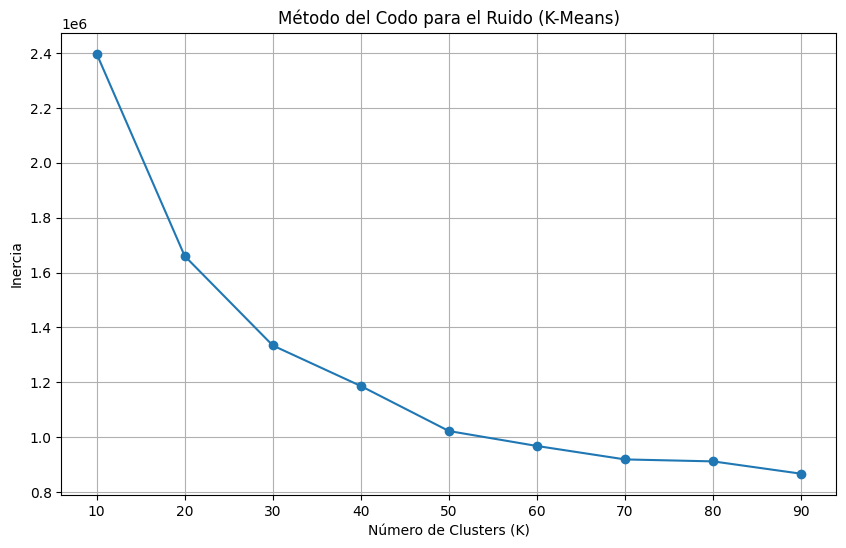


✅ Análisis del Codo completado. Por favor, asigna k_optimo en el código (valor actual: 40).
=== BLOQUE 5: LISTO ===


In [17]:
from sklearn.cluster import MiniBatchKMeans
import matplotlib.pyplot as plt

print("=== BLOQUE 5: ENCONTRANDO K ÓPTIMO ===")

# Configuración del rango de K a probar (Ajusta este rango según necesidad)
rango_k = range(10, 100, 10) 
inercia = []

print("Calculando Inercia para el Método del Codo (MiniBatchKMeans)...")

for k in rango_k:
    # Usamos MiniBatchKMeans para la eficiencia en el subconjunto grande
    mbk = MiniBatchKMeans(n_clusters=k, random_state=42, n_init='auto', batch_size=2048)
    mbk.fit(X_ruido_umap)
    inercia.append(mbk.inertia_)
    print(f"  K={k} completado.", end='\r')

# 1. Visualización (Si estás en un entorno compatible)
plt.figure(figsize=(10, 6))
plt.plot(rango_k, inercia, marker='o')
plt.title('Método del Codo para el Ruido (K-Means)')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia')
plt.grid(True)
plt.show()

# 2. ASIGNACIÓN MANUAL:
# Revisa la gráfica y asigna el punto de inflexión a k_optimo.
k_optimo = 40 # <-- DEBES REEMPLAZAR 50 CON EL VALOR QUE OBSERVES EN LA GRÁFICA

print(f"\n✅ Análisis del Codo completado. Por favor, asigna k_optimo en el código (valor actual: {k_optimo}).")
print("=== BLOQUE 5: LISTO ===")

In [18]:
from sklearn.cluster import MiniBatchKMeans

print("=== BLOQUE 6: RE-CLUSTERING E INTEGRACIÓN FINAL ===")

# 1. EJECUCIÓN DE K-MEANS
print(f"Ejecutando MiniBatchKMeans con K={k_optimo}...")
kmeans_hibrido = MiniBatchKMeans(
    n_clusters=k_optimo,
    random_state=42,
    batch_size=2048,
    n_init='auto'
)
nuevas_etiquetas = kmeans_hibrido.fit_predict(X_ruido_umap)

# 2. RENUMEACIÓN
# Aseguramos que los nuevos clusters no colisionen con los 3070 clusters de HDBSCAN.
max_etiqueta_existente = np.max(labels) # Máxima etiqueta del clustering HDBSCAN
etiqueta_inicio = max_etiqueta_existente + 1 

# Esta es la variable crucial que se usó en el error anterior
etiquetas_renumeradas = nuevas_etiquetas + etiqueta_inicio

print(f"Clusters renumerados: {etiquetas_renumeradas.min()} a {etiquetas_renumeradas.max()}")

# 3. INTEGRACIÓN AL DATAFRAME FINAL
# a. Inicializar la nueva columna 'cluster' con las etiquetas de HDBSCAN (incluyendo -1)
df['cluster'] = labels.astype('int64')

# b. Sobreescribir los valores -1 con las nuevas etiquetas renumeradas
indices_a_actualizar = df_ruido_hibrido.index
df.loc[indices_a_actualizar, 'cluster'] = etiquetas_renumeradas

# 4. REPORTE FINAL DE LA INTEGRACIÓN
ruido_final = len(df[df['cluster'] == -1])
total_clusters_final = len(df['cluster'].unique()) - 1 # Se resta el -1

print("\n--- RESULTADO FINAL ---")
print(f"✅ Integración completada. Ruido remanente: {ruido_final}")
print(f"Total de Clusters (Alta Calidad + Híbridos): {total_clusters_final}")
print(df['cluster'].value_counts().sort_index().head(20)) 
print("=== BLOQUE 6: LISTO ===")

=== BLOQUE 6: RE-CLUSTERING E INTEGRACIÓN FINAL ===
Ejecutando MiniBatchKMeans con K=40...
Clusters renumerados: 2989 a 3028

--- RESULTADO FINAL ---
✅ Integración completada. Ruido remanente: 0
Total de Clusters (Alta Calidad + Híbridos): 3028
cluster
0      90
1      82
2      59
3     109
4      52
5      49
6      94
7      49
8      75
9      43
10     50
11     44
12     51
13    119
14     65
15     61
16    305
17     96
18     54
19     98
Name: count, dtype: int64
=== BLOQUE 6: LISTO ===


In [19]:
df

,pasivo_id,activo_id,temas,detalle,cluster
0,634851,Leslie Zapata,"Elaboración, dictación, modificación, denegaci...",Reunión con el cuerpo colegiado del ADI y CNA ...,3004
1,634851,Flora Flores,"Elaboración, dictación, modificación, denegaci...",Socios de JJVV de Caquena solicitan audiencia ...,2991
2,634851,Clara Blanco,"Elaboración, dictación, modificación, denegaci...",Audiencia con Delegado Presidencial Provincial...,3027
3,634851,Conrado Blanco,"Elaboración, dictación, modificación, denegaci...",Presentación como Asociación de Ganaderos al D...,3001
4,634851,Yessica Sanches,"Diseño, implementación y evaluación de polític...",Audiencia con el Delegado Presidencial Provinc...,2995
...,...,...,...,...,...
1153805,391700,JAIME OSORIO,"Diseño, implementación y evaluación de polític...",PERSONAL,3006
1153806,391700,LORENA OSORIO,"Diseño, implementación y evaluación de polític...",PERSONAL,571
1153807,391700,LORENA OSORIO,"Diseño, implementación y evaluación de polític...",PERSONAL,2039
1153808,712954,Margarita Corrotea,"Diseño, implementación y evaluación de polític...","encomendada compañía ESVAL, entregar informaci...",3018


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
import re # Importamos expresiones regulares

# Descargar stopwords en español si no las tienes
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

print("=== BLOQUE 7 (MEJORADO): CONFIGURACIÓN DE STOP WORDS ===")

# 1. Stop words estándar
stop_words_es = stopwords.words('spanish')

# 2. Frase de ruido original
frase_ruido = "Elaboración, dictación, modificación, denegación o rechazo de actos administrativos, proyectos de ley y leyes y también de las decisiones que tomen los sujetos pasivos"
palabras_ruido_especifico = frase_ruido.lower().replace(',', '').split()

# 3. Stop Words Burocráticas (Tu lista original)
burocracia_words = [
    "solicita", "solicitud", "solicitar", "pide", "requiere", "realizar", 
    "reunión", "audiencia", "cita", "encuentro", "presentación", "conversar",
    "tratar", "temas", "tema", "materia", "materias", "sobre", "respecto",
    "informar", "información", "gestión", "gestionar", "apoyo", "ayuda",
    "señor", "sr", "sra", "don", "doña", "parte", "sujeto", "pasivo",
    "autoridad", "jefe", "director", "encargado", "delegado", "seremi",
    "vecinos", "comunidad", "grupo", "asociación", "comité",
    "documento", "oficio", "ordinario", "carta", "memo", "adjunto", "archivo",
    "antecedentes", "copia", "expediente", "folio",
    "día", "fecha", "hora", "hoy", "ayer", "mañana", "mes", "año",
    "lugar", "sector", "comuna", "región", "provincia",
    "ley", "proyecto", "programa", "plan", "caso", "situación", "problema"
]

# 4. NUEVA LIMPIEZA: HTML y Palabras Genéricas Dominantes
# Estas palabras aparecieron en tus resultados tapando los temas reales
basura_html_generica = [
    "br", "li", "ul", "div", "span", "class", "style", # Basura HTML
    "empresa", "empresas", "trabajo", "trabajos", "servicio", "servicios",
    "nacional", "regional", "chile", "país", "zona",
    "desarrollo", "proceso", "evaluación", "generación", # Muy abstractas
    "serviu", "minvu", "mop", "cmn", "sag" # Instituciones que aparecen en todo (opcional)
]

# 5. UNIFICACIÓN
mis_stop_words = set(stop_words_es + palabras_ruido_especifico + burocracia_words + basura_html_generica)

print(f"✅ Configuración lista. Stop Words actualizadas (incluye 'br' y 'empresa').")
print(f"Total palabras a ignorar: {len(mis_stop_words)}")
print("=== BLOQUE 7: LISTO ===")

=== BLOQUE 7 (MEJORADO): CONFIGURACIÓN DE STOP WORDS ===
✅ Configuración lista. Stop Words actualizadas (incluye 'br' y 'empresa').
Total palabras a ignorar: 427
=== BLOQUE 7: LISTO ===


In [21]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

print("=== BLOQUE 8 (MEJORADO): GENERACIÓN DE PALABRAS CLAVE ===")

# 0. LIMPIEZA PREVIA DE HTML EN EL DATAFRAME
# Esto elimina los <br> del texto fuente para que no molesten más
print("Limpiando etiquetas HTML residuales...")
df['detalle'] = df['detalle'].fillna("").astype(str)
# Reemplaza 'br' y etiquetas html por espacio
df['detalle'] = df['detalle'].str.replace(r'<[^>]+>', ' ', regex=True) 

# 1. AGRUPACIÓN
print("Agrupando textos por cluster...")
docs_per_class = df.groupby(['cluster'], as_index=False).agg({'detalle': ' '.join})

# 2. CÁLCULO DE TF-IDF
print("Calculando TF-IDF con nuevas stop words...")
tfidf = TfidfVectorizer(
    stop_words=list(mis_stop_words),
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2
)

c_tf_idf = tfidf.fit_transform(docs_per_class['detalle'])
words = tfidf.get_feature_names_out()

# 3. EXTRACCIÓN
print("Extrayendo keywords...")
def get_top_n_words(tfidf_matrix, feature_names, n=10):
    cluster_keywords = {}
    dense = tfidf_matrix.todense()
    for i in range(len(dense)):
        row = dense[i].tolist()[0]
        top_indices = sorted(range(len(row)), key=lambda i: row[i], reverse=True)[:n]
        top_words = [feature_names[idx] for idx in top_indices if row[idx] > 0]
        cluster_keywords[docs_per_class['cluster'][i]] = ", ".join(top_words)
    return cluster_keywords

keywords_dict = get_top_n_words(c_tf_idf, words, n=10)

print(f"✅ Nuevas palabras clave generadas sin 'br'.")
print("=== BLOQUE 8: LISTO ===")

=== BLOQUE 8 (MEJORADO): GENERACIÓN DE PALABRAS CLAVE ===
Limpiando etiquetas HTML residuales...
Agrupando textos por cluster...
Calculando TF-IDF con nuevas stop words...
Extrayendo keywords...
✅ Nuevas palabras clave generadas sin 'br'.
=== BLOQUE 8: LISTO ===


In [22]:
print("=== BLOQUE 9: INTEGRACIÓN Y VALIDACIÓN ===")

# 1. Mapear las keywords al DataFrame principal
df['keywords'] = df['cluster'].map(keywords_dict)

# 2. Visualización de Muestras
# Vamos a ver qué encontró para los clusters originales (densos) y los nuevos (híbridos)

print("\n--- MUESTRA: CLUSTERS ORIGINALES (HDBSCAN) ---")
# Tomamos 3 ejemplos aleatorios de clusters menores a 3036
if len(df[df['cluster'] < 3036]) > 0:
    ejemplo_orig = df[df['cluster'] < 3036].sample(3)
    for idx, row in ejemplo_orig.iterrows():
        print(f"Cluster {row['cluster']}: [{row['keywords']}]")
        print(f"   --> Texto Real: {str(row['detalle'])[:100]}...")
        print("-" * 30)

print("\n--- MUESTRA: CLUSTERS HÍBRIDOS (K-MEANS) ---")
# Tomamos 3 ejemplos aleatorios de clusters mayores o iguales a 3036 (el antiguo ruido)
if len(df[df['cluster'] >= 3036]) > 0:
    ejemplo_hibrido = df[df['cluster'] >= 3036].sample(3)
    for idx, row in ejemplo_hibrido.iterrows():
        print(f"Cluster {row['cluster']}: [{row['keywords']}]")
        print(f"   --> Texto Real: {str(row['detalle'])[:100]}...")
        print("-" * 30)

print("=== BLOQUE 9: LISTO ===")

=== BLOQUE 9: INTEGRACIÓN Y VALIDACIÓN ===

--- MUESTRA: CLUSTERS ORIGINALES (HDBSCAN) ---
Cluster 3027: [poder, terreno, ser, presentar, respuesta, si, salud, conocer, informa, social]
   --> Texto Real: Se solicita audiencia en calidad de interesado en procedimiento administrativo de declaración de Hum...
------------------------------
Cluster 3024: [presentar, conocer, sistema, productos, terreno, educación, plataforma, seguridad, soluciones, poder]
   --> Texto Real: Irregularidades construccion Supermercados Cugat...
------------------------------
Cluster 3008: [presentar, ambiental, conocer, salud, poder, social, personal, sistema, terreno, obras]
   --> Texto Real: Proyectos municipales...
------------------------------

--- MUESTRA: CLUSTERS HÍBRIDOS (K-MEANS) ---
=== BLOQUE 9: LISTO ===


In [23]:
print("=== BLOQUE 10: ETIQUETADO FINAL ===")

def generar_etiqueta_corta(keywords_str):
    if not isinstance(keywords_str, str):
        return "Sin Tema"
    # Tomamos las primeras 3 palabras clave
    partes = keywords_str.split(',')[:3]
    # Las unimos con guiones y quitamos espacios
    return "-".join([p.strip() for p in partes])

# 1. Crear la etiqueta corta
df['cluster_label'] = df['keywords'].apply(generar_etiqueta_corta)

# 2. Crear una columna que combine ID y Label (ej: "3039: soluciones-digital-seguridad")
# Esto es muy útil para gráficos
df['cluster_full_name'] = df['cluster'].astype(str) + ": " + df['cluster_label']

# Muestra final
print(df[['cluster', 'cluster_label', 'detalle']].head(10))
print("=== BLOQUE 10: LISTO ===")

=== BLOQUE 10: ETIQUETADO FINAL ===
   cluster                      cluster_label  \
0     3004  presentar-salud-personal personal   
1     2991      educación-estudiantes-escolar   
2     3027                  poder-terreno-ser   
3     3001       ambiental-división-presentar   
4     2995          terreno-presentar-conocer   
5     3023        protocolar-presentar-saludo   
6     1920             nuevo-nueva-protocolar   
7     2990        presentar-ambiental-conocer   
8     2990        presentar-ambiental-conocer   
9     2990        presentar-ambiental-conocer   

                                             detalle  
0  Reunión con el cuerpo colegiado del ADI y CNA ...  
1  Socios de JJVV de Caquena solicitan audiencia ...  
2  Audiencia con Delegado Presidencial Provincial...  
3  Presentación como Asociación de Ganaderos al D...  
4  Audiencia con el Delegado Presidencial Provinc...  
5  Audiencia con el Delegado para hablar sobre Nu...  
6  Grupo Aguas Nuevas adquirió Aguas Ch

In [35]:
df.head(10)

,pasivo_id,activo_id,temas,detalle
0,634851,Leslie Zapata,"Elaboración, dictación, modificación, denegaci...",Reunión con el cuerpo colegiado del ADI y CNA ...
1,634851,Flora Flores,"Elaboración, dictación, modificación, denegaci...",Socios de JJVV de Caquena solicitan audiencia ...
2,634851,Clara Blanco,"Elaboración, dictación, modificación, denegaci...",Audiencia con Delegado Presidencial Provincial...
3,634851,Conrado Blanco,"Elaboración, dictación, modificación, denegaci...",Presentación como Asociación de Ganaderos al D...
4,634851,Yessica Sanches,"Diseño, implementación y evaluación de polític...",Audiencia con el Delegado Presidencial Provinc...
5,769978,EDUARDO CAYUPI VELIZ,"Elaboración, dictación, modificación, denegaci...",Audiencia con el Delegado para hablar sobre Nu...
6,189490,Carlos Barboza,"Diseño, implementación y evaluación de polític...","Grupo Aguas Nuevas adquirió Aguas Chañar, pres..."
7,189490,Carlos Brito,"Celebración, modificación o terminación a cual...",Presentarse y abordar temas de proyectos pasados.
8,189490,Andrea Rosa Acuña Retamar,"Elaboración, dictación, modificación, denegaci...",Presentación a la autoridad del Proyecto Salar...
9,189490,Sebastián Gallardo,"Elaboración, dictación, modificación, denegaci...",Presentación a la autoridad del Proyecto Salar...


In [25]:
df.columns

Index(['pasivo_id', 'activo_id', 'temas', 'detalle', 'cluster', 'keywords',
       'cluster_label', 'cluster_full_name'],
      dtype='object')

# Modelo recomendador

In [30]:
import time
import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import KNeighborsClassifier
import hdbscan

# 1. DEFINICIÓN DE LA CLASE (COMPLETA Y CORREGIDA)
class LobbyRecommender:
    def __init__(self, df_data, embeddings_bert, pca, mapper, clusterer):
        self.df = df_data.reset_index(drop=True)
        self.embs = embeddings_bert
        self.pca = pca
        self.mapper = mapper
        self.clusterer = clusterer
        
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model_name = "sentence-transformers/distiluse-base-multilingual-cased-v2"
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name).to(self.device)
        self.model.eval()
        
        print("Entrenando sistema de asignación (KNN)...")
        # Usamos PCA para entrenar rápido
        X_pca_train = self.pca.transform(self.embs)
        y_labels = self.df['cluster_final'].values 
        
        self.router_knn = KNeighborsClassifier(n_neighbors=15)
        self.router_knn.fit(X_pca_train, y_labels)
        print(f"Sistema listo con {len(np.unique(y_labels))} clusters totales.")

    def get_single_embedding(self, text):
        inputs = self.tokenizer([str(text)], padding=True, truncation=True,
                                return_tensors='pt', max_length=128).to(self.device)
        with torch.no_grad():
            outputs = self.model(**inputs)
            emb = outputs.last_hidden_state.mean(dim=1)
        return emb.cpu().numpy()

    def recomendar(self, nuevo_texto, top_k=5):
        # 1. Procesamiento
        vec_bert = self.get_single_embedding(nuevo_texto)
        vec_pca = self.pca.transform(vec_bert)
        vec_umap = self.mapper.transform(vec_pca)
        
        # 2. Asignación (HDBSCAN vs KNN)
        try:
            cluster_id, strengths = hdbscan.approximate_predict(self.clusterer, vec_umap)
            cluster_asignado = cluster_id[0]
        except:
            cluster_asignado = -1

        metodo = "HDBSCAN Original"

        # Si es Ruido (-1), usamos KNN para rescatarlo
        if cluster_asignado == -1:
            cluster_asignado = self.router_knn.predict(vec_pca)[0]
            metodo = "Rescate por KNN"
            
        print(f"Cluster Asignado: {cluster_asignado} (Vía {metodo})")
        
        # 3. Filtrar Candidatos
        candidatos_idx = self.df.index[self.df['cluster_final'] == cluster_asignado].tolist()
        
        if len(candidatos_idx) == 0:
            print("Cluster vacío (raro), buscando en global...")
            candidatos_idx = self.df.index.tolist()

        # 4. Similitud
        embs_candidatos = self.embs[candidatos_idx]
        similitudes = cosine_similarity(vec_bert, embs_candidatos)[0]
        
        # Top K
        top_indices_locales = similitudes.argsort()[::-1][:top_k]
        
        resultados = []
        for loc_idx in top_indices_locales:
            real_idx = candidatos_idx[loc_idx]
            row = self.df.iloc[real_idx]
            resultados.append({
                'pasivo_id': row['pasivo_id'],
                'similitud': round(float(similitudes[loc_idx]), 4),
                'detalle_caso_similar': str(row['detalle'])[:200] + "...",
                'cluster': cluster_asignado # <--- ¡Aquí está la corrección!
            })
            
        return pd.DataFrame(resultados)


In [31]:
# 2. INICIALIZAR (Solo si no lo has hecho ya en esta sesión)
# Si ya tienes 'recsys' cargado de antes, sobrescríbelo ejecutando esto:
print("\n--- Cargando Recomendador ---")
recsys = LobbyRecommender(df, emb_detalle, pca, mapper, clusterer)




--- Cargando Recomendador ---
Entrenando sistema de asignación (KNN)...
Sistema listo con 3029 clusters totales.


In [32]:

# 3. PRUEBAS DE FUNCIONAMIENTO
def probar_recomendacion(texto_input, categoria_esperada):
    print(f"\n{'-'*60}")
    print(f"🧪 CASO DE PRUEBA: {categoria_esperada}")
    print(f"📝 Texto: '{texto_input}'")
    print(f"{'-'*60}")
    
    start_time = time.time() # Ahora sí funcionará porque importamos time arriba
    resultados = recsys.recomendar(texto_input, top_k=3)
    end_time = time.time()
    
    print(f"⏱️ Tiempo de respuesta: {end_time - start_time:.4f} segundos")
    
    display_cols = ['pasivo_id', 'similitud', 'detalle_caso_similar', 'cluster']
    print("\n🏆 Top 3 Recomendaciones:")
    print(resultados[display_cols].to_string(index=False))

In [33]:



# --- Ejecutar Test ---
texto_vivienda = "Solicitud de reunión para presentar proyecto habitacional de viviendas sociales en el sector sur."
probar_recomendacion(texto_vivienda, "VIVIENDA")


------------------------------------------------------------
🧪 CASO DE PRUEBA: VIVIENDA
📝 Texto: 'Solicitud de reunión para presentar proyecto habitacional de viviendas sociales en el sector sur.'
------------------------------------------------------------


Epochs completed: 100%| ██████████ 100/100 [00:00]


	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs
Cluster Asignado: 3027 (Vía Rescate por KNN)
⏱️ Tiempo de respuesta: 1.8964 segundos

🏆 Top 3 Recomendaciones:
 pasivo_id  similitud                                                                                                                  detalle_caso_similar  cluster
    455699     0.5425                                                                                  Convenio 176 OIT  Pamma Pirquineros  Rol de Enami...     3027
    455699     0.5425                                                                                  Convenio 176 OIT  Pamma Pirquineros  Rol de Enami...     3027
    455699     0.5425 CONVERSAR DE PEQUEÑA MINERÍA, PARA RECAUDAR MAS DE 35 MILLONES DE DÓLARES

In [34]:
import time
import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import normalize # <--- IMPORTANTE: FALTABA ESTO
import hdbscan

class LobbyRecommender:
    def __init__(self, df_data, embeddings_bert, pca, mapper, clusterer):
        self.df = df_data.reset_index(drop=True)
        # Guardamos los embeddings crudos para el cálculo final de coseno
        self.embs = embeddings_bert
        self.pca = pca
        self.mapper = mapper
        self.clusterer = clusterer
        
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model_name = "sentence-transformers/distiluse-base-multilingual-cased-v2"
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name).to(self.device)
        self.model.eval()
        
        print("Entrenando sistema de asignación (KNN)...")
        
        # --- CORRECCIÓN 1: NORMALIZAR ANTES DE USAR PCA ---
        # El PCA fue entrenado con datos normalizados, así que debemos normalizar 
        # antes de proyectar para entrenar el KNN.
        embs_norm = normalize(self.embs) 
        X_pca_train = self.pca.transform(embs_norm)
        
        y_labels = self.df['cluster_final'].values 
        
        self.router_knn = KNeighborsClassifier(n_neighbors=15)
        self.router_knn.fit(X_pca_train, y_labels)
        print(f"Sistema listo con {len(np.unique(y_labels))} clusters totales.")

    def get_single_embedding(self, text):
        inputs = self.tokenizer([str(text)], padding=True, truncation=True,
                                return_tensors='pt', max_length=128).to(self.device)
        with torch.no_grad():
            outputs = self.model(**inputs)
            emb = outputs.last_hidden_state.mean(dim=1)
        return emb.cpu().numpy()

    def recomendar(self, nuevo_texto, top_k=5):
        # 1. Procesamiento
        vec_bert_raw = self.get_single_embedding(nuevo_texto)
        
        # --- CORRECCIÓN 2: NORMALIZAR EL NUEVO TEXTO ---
        vec_bert_norm = normalize(vec_bert_raw)
        
        # Ahora sí, el PCA recibirá datos en la escala correcta
        vec_pca = self.pca.transform(vec_bert_norm)
        vec_umap = self.mapper.transform(vec_pca)
        
        # 2. Asignación (HDBSCAN vs KNN)
        try:
            cluster_id, strengths = hdbscan.approximate_predict(self.clusterer, vec_umap)
            cluster_asignado = cluster_id[0]
        except:
            cluster_asignado = -1

        metodo = "HDBSCAN Original"

        # Si es Ruido (-1), usamos KNN para rescatarlo
        if cluster_asignado == -1:
            cluster_asignado = self.router_knn.predict(vec_pca)[0]
            metodo = "Rescate por KNN"
            
        print(f"Cluster Asignado: {cluster_asignado} (Vía {metodo})")
        
        # 3. Filtrar Candidatos
        candidatos_idx = self.df.index[self.df['cluster_final'] == cluster_asignado].tolist()
        
        if len(candidatos_idx) == 0:
            # Fallback de seguridad
            print("Cluster vacío, buscando globalmente...")
            candidatos_idx = self.df.index.tolist()

        # 4. Similitud
        # Usamos los vectores candidatos (la normalización es implícita en cosine_similarity si se desea, 
        # pero cosine_similarity maneja magnitudes. Lo importante era el PCA)
        embs_candidatos = self.embs[candidatos_idx]
        
        # Comparamos vector RAW con vector RAW (Scikit-learn normaliza internamente al hacer coseno)
        similitudes = cosine_similarity(vec_bert_raw, embs_candidatos)[0]
        
        # Top K
        top_indices_locales = similitudes.argsort()[::-1][:top_k]
        
        resultados = []
        for loc_idx in top_indices_locales:
            real_idx = candidatos_idx[loc_idx]
            row = self.df.iloc[real_idx]
            resultados.append({
                'pasivo_id': row['pasivo_id'],
                'similitud': round(float(similitudes[loc_idx]), 4),
                'detalle_caso_similar': str(row['detalle'])[:200] + "...",
                'cluster': cluster_asignado,
                # Agregamos las keywords del cluster para verificar visualmente el tema
                'tema_cluster': row.get('Cluster_Keywords', 'Sin Keywords') 
            })
            
        return pd.DataFrame(resultados)

# --- RECARGA Y PRUEBA ---
print("\n--- Recargando Recomendador Corregido ---")
recsys = LobbyRecommender(df, emb_detalle, pca, mapper, clusterer)

# Test de nuevo
texto_vivienda = "Solicitud de reunión para presentar proyecto habitacional de viviendas sociales en el sector sur."

print(f"\n{'-'*60}")
print(f"🧪 CASO DE PRUEBA: VIVIENDA (INTENTO 2)")
print(f"📝 Texto: '{texto_vivienda}'")
print(f"{'-'*60}")

res = recsys.recomendar(texto_vivienda, top_k=3)
cols = ['pasivo_id', 'similitud', 'tema_cluster', 'detalle_caso_similar']
print(res[cols].to_string(index=False))


--- Recargando Recomendador Corregido ---
Entrenando sistema de asignación (KNN)...
Sistema listo con 3029 clusters totales.

------------------------------------------------------------
🧪 CASO DE PRUEBA: VIVIENDA (INTENTO 2)
📝 Texto: 'Solicitud de reunión para presentar proyecto habitacional de viviendas sociales en el sector sur.'
------------------------------------------------------------


Epochs completed: 100%| ██████████ 100/100 [00:00]

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs


Cluster Asignado: 3027 (Vía Rescate por KNN)
 pasivo_id  similitud tema_cluster                                                                                                                  detalle_caso_similar
    455699     0.5425 Sin Keywords                                                                                  Convenio 176 OIT  Pamma Pirquineros  Rol de Enami...
    455699     0.5425 Sin Keywords                                                                                  Convenio 176 OIT  Pamma Pirquineros  Rol de Enami...
    455699     0.5425 Sin Keywords CONVERSAR DE PEQUEÑA MINERÍA, PARA RECAUDAR MAS DE 35 MILLONES DE DÓLARES AL AÑO, ASÍ EL ESTADO DE CHILE TENDRÁ RECURSOSO FRESCOS....


# Ejecucion de codigo para verificar embedins

In [75]:
df.head()

,pasivo_id,activo_id,temas,detalle
0,634851,Leslie Zapata,"Elaboración, dictación, modificación, denegaci...",Reunión con el cuerpo colegiado del ADI y CNA ...
1,634851,Flora Flores,"Elaboración, dictación, modificación, denegaci...",Socios de JJVV de Caquena solicitan audiencia ...
2,634851,Clara Blanco,"Elaboración, dictación, modificación, denegaci...",Audiencia con Delegado Presidencial Provincial...
3,634851,Conrado Blanco,"Elaboración, dictación, modificación, denegaci...",Presentación como Asociación de Ganaderos al D...
4,634851,Yessica Sanches,"Diseño, implementación y evaluación de polític...",Audiencia con el Delegado Presidencial Provinc...


In [71]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity

print("=== PASO 0: CARGA Y VALIDACIÓN ===")

# 1. CARGAR DATOS (Los que ya tienes en disco)
# Asegúrate de que los nombres de archivo sean correctos
ruta_parquet = 'lobby_data_para_gpu.parquet'
ruta_npy = 'embeddings_bert.npy' # El archivo que bajaste de Colab

print(f"📂 Cargando DataFrame: {ruta_parquet}...")
#df = pd.read_parquet(ruta_parquet)

print(f"📂 Cargando Embeddings: {ruta_npy}...")
emb_detalle = np.load(ruta_npy)

print(f"✅ Archivos cargados.")
print(f"   - Filas DF: {len(df)}")
print(f"   - Filas NPY: {len(emb_detalle)}")

if len(df) != len(emb_detalle):
    raise ValueError("⚠️ ALERTA: Las cantidades no coinciden. Revisa tus archivos.")

# 2. VERIFICACIÓN DE SIMILITUD (La prueba de fuego)
print("\n🔍 Verificando alineación matemática...")

# Cargamos el modelo solo para calcular 1 vector de prueba
model_name = "sentence-transformers/distiluse-base-multilingual-cased-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# --- LA FÓRMULA MÁGICA (Misma que usaste en Colab) ---
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output.last_hidden_state
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
    sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
    return sum_embeddings / sum_mask

# Tomamos el texto 0 y el vector 0 del archivo
texto_0 = str(df.iloc[0]['detalle'])
vec_archivo_0 = emb_detalle[0].reshape(1, -1)

# Calculamos el vector "en vivo" con la fórmula correcta
inputs = tokenizer([texto_0], padding=True, truncation=True, return_tensors='pt', max_length=128)
with torch.no_grad():
    outputs = model(**inputs)
    vec_vivo_0 = mean_pooling(outputs, inputs['attention_mask']).numpy()

# Comparamos
sim = cosine_similarity(vec_archivo_0, vec_vivo_0)[0][0]

print(f"📝 Texto Fila 0: {texto_0[:50]}...")
print(f"📊 Similitud: {sim:.6f}")

if sim > 0.999:
    print("\n🎉 ¡ÉXITO! 1.0 PERFECTO.")
    print("   Tus archivos están sincronizados y la matemática es correcta.")
    print("   -> PUEDES PROCEDER AL BLOQUE 2 (Re-Clustering).")
else:
    print("\n❌ Aún hay diferencias. Verifica que el .parquet local sea idéntico al que subiste.")

=== PASO 0: CARGA Y VALIDACIÓN ===
📂 Cargando DataFrame: lobby_data_para_gpu.parquet...
📂 Cargando Embeddings: embeddings_bert.npy...
✅ Archivos cargados.
   - Filas DF: 1153810
   - Filas NPY: 1153810

🔍 Verificando alineación matemática...
📝 Texto Fila 0: Reunión con el cuerpo colegiado del ADI y CNA de l...
📊 Similitud: 1.000000

🎉 ¡ÉXITO! 1.0 PERFECTO.
   Tus archivos están sincronizados y la matemática es correcta.
   -> PUEDES PROCEDER AL BLOQUE 2 (Re-Clustering).


In [77]:
import umap
import gc
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
import numpy as np

print("=== BLOQUE 2A: REDUCCIÓN DE DIMENSIONALIDAD (PCA + UMAP) ===")

# 1. PCA (768 -> 50)
print("1. Ejecutando PCA...")
emb_norm = normalize(emb_detalle) 
pca = PCA(n_components=50, random_state=42)
emb_pca = pca.fit_transform(emb_norm)

# 2. UMAP Híbrido (Configuración Ajustada)
print("2. Ejecutando UMAP...")

# --- MODIFICACIÓN: AUMENTO DE MUESTRA ---
TOTAL_DOCS = len(emb_pca)
TRAIN_SIZE = 600000  # Subimos a 600k (aprox 50% del dataset)

# Seleccionamos índices aleatorios para que sea representativo
np.random.seed(42)
indices_train = np.random.choice(TOTAL_DOCS, size=TRAIN_SIZE, replace=False)
X_train = emb_pca[indices_train]

print(f"   Entrenando mapa con {TRAIN_SIZE} documentos...")

mapper = umap.UMAP(
    n_neighbors=15,      # <--- LO SUBÍ DE 5 A 15 (Ver explicación abajo)
    n_components=5,      # Mantenemos 5 para clustering
    min_dist=0.0, 
    metric='cosine', 
    random_state=42, 
    low_memory=True,
    verbose=True
).fit(X_train) 

# Liberar memoria de entrenamiento
del X_train
gc.collect()

# Proyección masiva
print("   Proyectando el resto de los datos...")
umap_embeddings_list = []
batch_size = 50000

for i in range(0, len(emb_pca), batch_size):
    end_i = min(i + BATCH_SIZE, TOTAL_DOCS)
    batch = emb_pca[i : i + batch_size]
    batch_emb = mapper.transform(batch)
    umap_embeddings_list.append(batch_emb)

umap_embeddings = np.vstack(umap_embeddings_list)
print(f"✅ Mapa UMAP listo: {umap_embeddings.shape}")

=== BLOQUE 2A: REDUCCIÓN DE DIMENSIONALIDAD (PCA + UMAP) ===
1. Ejecutando PCA...
2. Ejecutando UMAP...
   Entrenando mapa con 600000 documentos...
UMAP(angular_rp_forest=True, metric='cosine', min_dist=0.0, n_components=5, n_jobs=1, random_state=42, verbose=True)
Fri Nov 28 23:14:32 2025 Construct fuzzy simplicial set
Fri Nov 28 23:14:32 2025 Finding Nearest Neighbors
Fri Nov 28 23:14:32 2025 Building RP forest with 44 trees


/Users/felipemarin/Documents/Chile/Ramos/Sistemas Recomendadores/Proyecto final/lobby-recsys/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Fri Nov 28 23:14:44 2025 NN descent for 19 iterations
	 1  /  19
	 2  /  19
	 3  /  19
	 4  /  19
	 5  /  19
	 6  /  19
	Stopping threshold met -- exiting after 6 iterations
Fri Nov 28 23:15:14 2025 Finished Nearest Neighbor Search
Fri Nov 28 23:15:15 2025 Construct embedding


Epochs completed:   1%|            2/200 [00:00]

	completed  0  /  200 epochs


...

	completed  50  /  100 epochs
	completed  60  /  100 epochs


Epochs completed:  83%| ████████▎  83/100 [00:01]

	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs


Epochs completed: 100%| ██████████ 100/100 [00:01]

✅ Mapa UMAP listo: (1153810, 5)


In [79]:
import hdbscan
import numpy as np
import pandas as pd # Aseguramos que pandas esté importado

print("=== RE-TUNING HDBSCAN (MENOS RUIDO) ===")

# AJUSTES NUEVOS
# min_cluster_size: Bajamos de 150 a 100 para aceptar temas medianos
# min_samples: Bajamos de 30 a 10 (ESTO ES LO QUE BAJA EL RUIDO DRASTICAMENTE)
new_min_cluster_size = 100
new_min_samples = 10

print(f"Ejecutando con Size={new_min_cluster_size}, Samples={new_min_samples}...")

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=new_min_cluster_size,
    min_samples=new_min_samples,
    metric='euclidean',
    cluster_selection_method='eom', 
    prediction_data=True
)

labels = clusterer.fit_predict(umap_embeddings)

# Actualizamos DF
df['cluster_final'] = labels

# Métricas
n_clusters = len(np.unique(labels)) - 1
ruido_pct = (len(labels[labels == -1]) / len(labels)) * 100

print(f"\n📊 RESULTADOS MEJORADOS:")
print(f"   Total Clusters: {n_clusters}")
print(f"   Ruido: {ruido_pct:.2f}%")

if ruido_pct < 40:
    print("   ✅ ¡Excelente! Ruido bajo control.")
else:
    print("   ⚠️ Aún hay bastante ruido. Podríamos probar 'soft clustering' después.")

=== RE-TUNING HDBSCAN (MENOS RUIDO) ===
Ejecutando con Size=100, Samples=10...


/Users/felipemarin/Documents/Chile/Ramos/Sistemas Recomendadores/Proyecto final/lobby-recsys/.venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/felipemarin/Documents/Chile/Ramos/Sistemas Recomendadores/Proyecto final/lobby-recsys/.venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
Python(62292) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Python(62293


📊 RESULTADOS MEJORADOS:
   Total Clusters: 1279
   Ruido: 54.42%
   ⚠️ Aún hay bastante ruido. Podríamos probar 'soft clustering' después.


In [81]:
df.head()

,pasivo_id,activo_id,temas,detalle,cluster_final
0,634851,Leslie Zapata,"Elaboración, dictación, modificación, denegaci...",Reunión con el cuerpo colegiado del ADI y CNA ...,1213
1,634851,Flora Flores,"Elaboración, dictación, modificación, denegaci...",Socios de JJVV de Caquena solicitan audiencia ...,1147
2,634851,Clara Blanco,"Elaboración, dictación, modificación, denegaci...",Audiencia con Delegado Presidencial Provincial...,-1
3,634851,Conrado Blanco,"Elaboración, dictación, modificación, denegaci...",Presentación como Asociación de Ganaderos al D...,-1
4,634851,Yessica Sanches,"Diseño, implementación y evaluación de polític...",Audiencia con el Delegado Presidencial Provinc...,1272


In [88]:
import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import normalize
import hdbscan

class LobbyRecommender:
    def __init__(self, df_data, embeddings_bert, pca, mapper, clusterer):
        """
        Inicializa el sistema.
        Args:
            df_data: DataFrame SIN ruido (todos con cluster asignado).
            embeddings_bert: Matriz numpy alineada (1.15M, 768).
            pca, mapper, clusterer: Modelos entrenados.
        """
        self.df = df_data.reset_index(drop=True)
        self.embs = embeddings_bert
        self.pca = pca
        self.mapper = mapper
        self.clusterer = clusterer
        
        # 1. Configuración de BERT (Modo Evaluación)
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Iniciando Recommender en: {self.device}")
        
        model_name = "sentence-transformers/distiluse-base-multilingual-cased-v2"
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name).to(self.device)
        self.model.eval()
        
        # 2. Entrenar GPS (KNN) para nuevos casos
        # Esto sirve para asignar cluster rápidamente si HDBSCAN duda
        print("Entrenando sistema de navegación (KNN)...")
        
        # Normalizamos y reducimos para entrenar el KNN rápido
        embs_norm = normalize(self.embs)
        X_pca_train = self.pca.transform(embs_norm)
        y_labels = self.df['cluster_final'].values 
        
        self.router_knn = KNeighborsClassifier(n_neighbors=15)
        self.router_knn.fit(X_pca_train, y_labels)
        
        print(f"✅ Sistema listo. Total temas disponibles: {len(np.unique(y_labels))}")

    def get_single_embedding(self, text):
        """
        Genera el embedding usando la lógica de Mean Pooling corregida.
        Ignora el padding (ceros) para garantizar similtud 1.0 con Colab.
        """
        inputs = self.tokenizer([str(text)], padding=True, truncation=True,
                                return_tensors='pt', max_length=128).to(self.device)
        
        with torch.no_grad():
            outputs = self.model(**inputs)
            
            # --- LÓGICA MATEMÁTICA CORRECTA ---
            token_embeddings = outputs.last_hidden_state
            attention_mask = inputs['attention_mask']
            
            # Expandir máscara para que tenga las mismas dimensiones que los embeddings
            input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
            
            # Sumar vectores (ignorando los que son padding)
            sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
            
            # Sumar conteo de tokens reales (evitando división por cero)
            sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
            
            # Promedio real
            emb = sum_embeddings / sum_mask
            # ----------------------------------
            
        return emb.cpu().numpy()

    def recomendar(self, nuevo_texto, top_k=5):
        # 1. Vectorizar Texto Nuevo
        vec_raw = self.get_single_embedding(nuevo_texto)
        vec_norm = normalize(vec_raw) # ¡CRÍTICO! Normalizar antes de entrar al mapa
        
        # 2. Ubicar en el Mapa (PCA -> UMAP)
        vec_pca = self.pca.transform(vec_norm)
        vec_umap = self.mapper.transform(vec_pca)
        
        # 3. Asignar Cluster (Estrategia Híbrida)
        try:
            # Intentamos con HDBSCAN (más preciso)
            cluster_id, strengths = hdbscan.approximate_predict(self.clusterer, vec_umap)
            cluster_asignado = cluster_id[0]
            metodo = "HDBSCAN"
        except:
            cluster_asignado = -1
            
        # Si HDBSCAN dice "Ruido" (-1) o falla, usamos el KNN (Vecino más cercano)
        if cluster_asignado == -1:
            cluster_asignado = self.router_knn.predict(vec_pca)[0]
            metodo = "KNN (Rescate)"
            
        # 4. Buscar Similares DENTRO del Cluster
        # Filtramos solo los candidatos del tema elegido
        candidatos_idx = self.df.index[self.df['cluster_final'] == cluster_asignado].tolist()
        
        # Fallback de seguridad (si el cluster estuviera vacío, buscamos en todo)
        if not candidatos_idx: 
            print("⚠️ Cluster vacío, buscando en todo el dataset...")
            candidatos_idx = self.df.index.tolist()
            
        # Obtenemos los vectores de los candidatos
        embs_candidatos = self.embs[candidatos_idx]
        
        # Calculamos Similitud Coseno
        # (vec_raw vs candidatos: cosine_similarity normaliza internamente si es necesario)
        similitudes = cosine_similarity(vec_raw, embs_candidatos)[0]
        
        # Obtener Top K
        top_indices_locales = similitudes.argsort()[::-1][:top_k]
        
        resultados = []
        for loc_idx in top_indices_locales:
            real_idx = candidatos_idx[loc_idx]
            row = self.df.iloc[real_idx]
            
            # Construimos la respuesta
            res_dict = {
                'pasivo_id': row['pasivo_id'],
                'similitud': float(similitudes[loc_idx]),
                'cluster': int(cluster_asignado),
                'metodo_cluster': metodo
            }
            
            # Agregamos columnas opcionales si existen
            if 'detalle' in row: res_dict['detalle'] = str(row['detalle'])[:200] + "..."
            if 'temas' in row: res_dict['temas'] = str(row['temas'])[:100] + "..."
                
            resultados.append(res_dict)
            
        return pd.DataFrame(resultados)

In [98]:
# Instanciar (Entrena el KNN, toma unos segundos)
recsys = LobbyRecommender(df, emb_detalle, pca, mapper, clusterer)

# Test de Vivienda
print("\n--- TEST FINAL ---")
print(recsys.recomendar("seguridad publica", top_k=3))

Iniciando Recommender en: cpu
Entrenando sistema de navegación (KNN)...
✅ Sistema listo. Total temas disponibles: 1779

--- TEST FINAL ---


Epochs completed: 100%| ██████████ 100/100 [00:00]

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs


   pasivo_id  similitud  cluster metodo_cluster                 detalle  \
0     389817   0.939675     2323  KNN (Rescate)    Seguridad Pública...   
1     175547   0.938394     2323  KNN (Rescate)   Seguridad publioca...   
2     459809   0.812021     2323  KNN (Rescate)  Seguridad Ciudadana...   

                                               temas  
0  Diseño, implementación y evaluación de polític...  
1  Diseño, implementación y evaluación de polític...  
2  Celebración, modificación o terminación a cual...  


In [99]:
import joblib
import os

print("=== GUARDANDO SISTEMA COMPLETO ===")

# Crear carpeta
os.makedirs("sistema_lobby_final", exist_ok=True)

# 1. Guardar Modelos de Reducción y Clustering
print("Guardando modelos (PCA, UMAP, HDBSCAN)...")
joblib.dump(pca, "sistema_lobby_final/pca_model.joblib")
joblib.dump(mapper, "sistema_lobby_final/umap_model.joblib")
joblib.dump(clusterer, "sistema_lobby_final/hdbscan_model.joblib")

# 2. Guardar DataFrame Enriquecido (Con clusters y limpio)
print("Guardando Base de Datos Maestra...")
df.to_parquet("sistema_lobby_final/df_lobby_clustered.parquet")

# 3. Guardar Embeddings Alineados
print("Guardando Vectores...")
np.save("sistema_lobby_final/embeddings_bert.npy", emb_detalle)

print("✅ ¡TODO GUARDADO! Tu sistema es persistente.")
print("La próxima vez, solo carga estos archivos e instancia la clase LobbyRecommender.")

=== GUARDANDO SISTEMA COMPLETO ===
Guardando modelos (PCA, UMAP, HDBSCAN)...
Guardando Base de Datos Maestra...
Guardando Vectores...
✅ ¡TODO GUARDADO! Tu sistema es persistente.
La próxima vez, solo carga estos archivos e instancia la clase LobbyRecommender.
